In [1]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast
# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()


# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [6]:
df_DA_US=df[(df['job_title_short']=='Data Analyst') & (df['job_country']=='United States')].copy()

df_DA_US=df_DA_US.dropna(subset=['salary_year_avg'])
df_DA_US['salary_year_avg'].sample(10)

600157     63000.0
212434    120000.0
448934     70200.0
582259     85000.0
411123     85000.0
770385     56212.5
415127     57500.0
628413     68900.0
636010    150000.0
284824    115000.0
Name: salary_year_avg, dtype: float64

<Axes: >

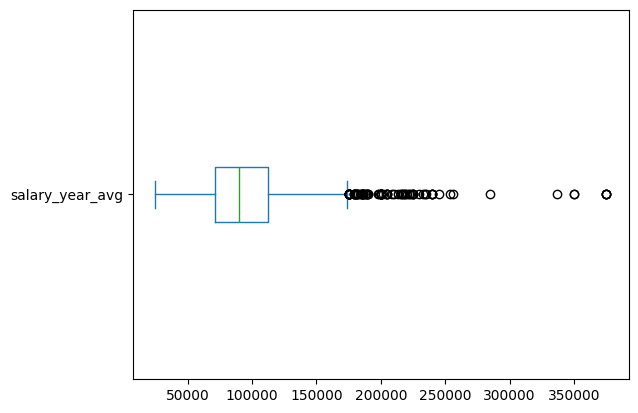

In [8]:
df_DA_US['salary_year_avg'].plot(kind='box',vert=False)

C:\Users\AdarshaB\AppData\Local\Temp\ipykernel_7412\4240526098.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_list,labels=job_titles,vert=False)


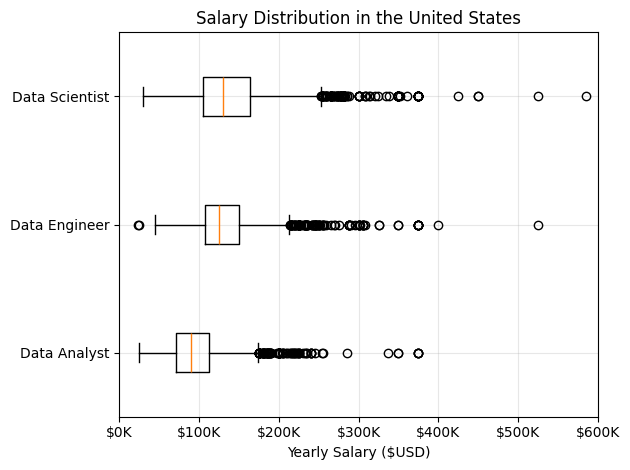

In [18]:
job_titles=['Data Analyst','Data Engineer','Data Scientist']

df_US=df[(df['job_title_short'].isin(job_titles) ) & (df['job_country']=='United States') ] .copy()
df_US=df_US.dropna(subset=['salary_year_avg'])
job_list=[df_US[df_US['job_title_short']==job_title]['salary_year_avg'] for job_title in job_titles]
plt.boxplot(job_list,labels=job_titles,vert=False)
plt.title('Salary Distribution in the United States')
plt.xlabel('Yearly Salary ($USD)')

# Format x-axis to show in thousands (K)
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))

# Set x-axis limits
plt.xlim(0, 600000)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
